# 6. Supersegments and access prediction

Given one catheter pathway, how hard will it be to reach the target? ArterialGNet answers with a probability of difficult access, averaged over five models, plus an attention map that shows which part of the pathway drove the answer.

This uses the supersegments from notebook 5 and runs in seconds on a GPU.

In [1]:
import os, numpy as np, torch, matplotlib.pyplot as plt
from arterial_nb import *
from arterial import model_registry
from arterial.io.load_and_save_operations import load_json
from arterial.access_prediction.access_predictor import AccessPredictor

predictor = AccessPredictor(case("access"), fixture("cta.nii.gz"), supersegments_dir_path=derived("supersegments"), access=["femoral"], side=["left", "right"])
with timed("preprocessing"), quiet():
    predictor.preprocess_supersegments(save=True)
plt.close("all")   # the stage saves its own plots to disk; no need to show them here


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



preprocessing: 0.8 s


## What the model sees

Each pathway is turned into two graphs plus a short vector. The **dense graph** is the pathway itself, one node every 2 mm with its local features. The **segment graph** has one node per named vessel with the segment features. The **global vector** holds the arch type and a few pathway-level numbers. Everything is normalised with the statistics stored next to the weights.

In [2]:
rows = []
for key, pre in predictor.preprocessed_supersegment_dict.items():
    rows.append([" + ".join(key), pre["dense_graph"].number_of_nodes(), pre["segment_graph"].number_of_nodes(), len(pre["global_features"]["features_list"])])
table(rows, columns=["pathway", "dense nodes", "segment nodes", "global features"])

,pathway,dense nodes,segment nodes,global features
0,femoral + left,180,4,22
1,femoral + right,209,4,22


In [3]:
description = load_json(model_registry.model_path("access_prediction", "dataset.json"))
table([[n] for n in description["global_feature_names"]], columns=["global feature"]).T

,0,1,2,3,4,5,6,7,8
global feature,side,tortuosity_index,length,mean_diameter,std_diameter,min_polar_angle,polar_angle,azimuthal_angle,vessel_type


## The network

The checkpoint stores the architecture it was trained with. The dense path is a graph attention layer over the pathway, pooled into one vector; the output layer turns it into two class probabilities. The attention weights of that first layer are what the attention map shows.

In [4]:
state = torch.load(model_registry.model_path("access_prediction", "fold_0", "model_weights.pth"), map_location="cpu", weights_only=False)
kwargs = {k: v for k, v in state["init_kwargs"].items() if not callable(v) and k not in ("training", "global_path", "segment_path")}
table([[k, v] for k, v in kwargs.items()], columns=["argument", "value"]).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
argument,global_in_dim,segment_node_in_dim,segment_edge_in_dim,dense_node_in_dim,hidden_dim,hidden_dim_dense,out_dim,num_global_layers,num_segment_layers,num_dense_layers,num_out_layers,attn_heads,aggregation_,dropout,concat,is_classification
value,22,21,6,25,32,32,2,0,0,1,1,8,mean,0.2,False,True


In [5]:
with timed("prediction, 5 folds, both sides"), quiet():
    predictor.predict_accessibility(return_attention_map=True, save=True)
rows = [[" + ".join(k), round(float(v["mean"]), 3), round(float(v["std"]), 3)] for k, v in predictor.predictions_dict.items()]
table(rows, columns=["pathway", "P(difficult access)", "spread across folds"])

prediction, 5 folds, both sides: 0.9 s


,pathway,P(difficult access),spread across folds
0,femoral + left,0.636,0.321
1,femoral + right,0.839,0.304


## Attention map

Every edge of the pathway gets the attention the network paid to it, averaged over heads and folds; nodes take the mean of their edges. High attention marks the region that made the pathway look difficult. The same map is written as a VTK file and a JSON of points so it can be opened in 3D Slicer next to the CTA.

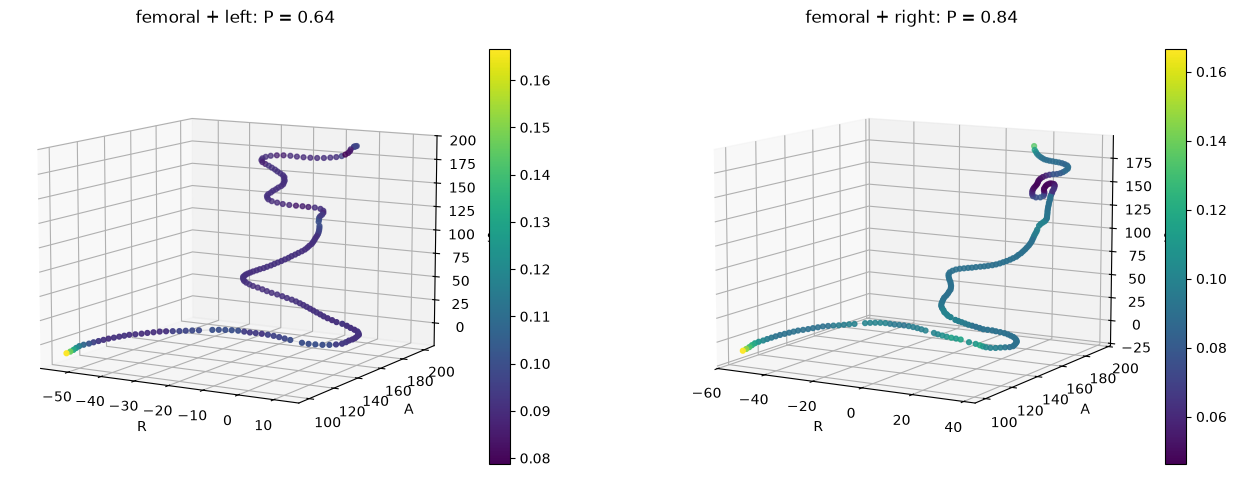

In [6]:
fig = plt.figure(figsize=(16, 9))
for idx, (key, graph) in enumerate(predictor.attention_maps_dict.items()):
    plot_graph(graph, color_by=lambda d: d["features femoral"]["attention_weight"], ax=fig.add_subplot(1, 2, idx + 1, projection="3d"),
               title=f"{' + '.join(key)}: P = {predictor.predictions_dict[key]['mean']:.2f}", node_size=12)

In [7]:
out_dir = predictor.access_prediction_dir_path
table([[os.path.relpath(os.path.join(r, f), out_dir), round(os.path.getsize(os.path.join(r, f)) / 1e3, 1)] for r, _, fs in os.walk(out_dir) for f in sorted(fs)], columns=["output", "kB"])

,output,kB
0,femoral_right/access_prediction.json,0.1
1,femoral_right/attention_map.pickle,25.9
2,femoral_right/attention_map.png,31.9
3,femoral_right/attention_map.vtk,8.0
4,femoral_right/attention_map_points.json,30.0
5,femoral_right/combined_plot.png,96.1
6,femoral_right/dense_supersegment.pickle,145.5
7,femoral_right/global_features.json,0.9
8,femoral_right/preprocessed_supersegment_dict.p...,204.1
9,femoral_right/segment_supersegment.pickle,78.1


## Notes

- The spread across the five folds is the model's own uncertainty; a large spread with a middling probability is a case to review by eye.
- Only the femoral anterior pathways have a trained model today; radial and posterior supersegments are produced but not scored.
- A pathway that collapses to a single segment (for example when labelling failed upstream) is rejected with a clear error rather than scored.